In [28]:
import os
import glob
import json

import pandas as pd
import matplotlib.pyplot as plt

from eval.dataset import load_json

In [29]:
# preparation

def check_json(x: str):
    try:
        if x.startswith("```json"):
            x = x.replace("```json", "")
            x = x.replace("```", "")
            json.loads(x.strip())
            return 1
        else:
            if "status:" in x:
                x = x.replace("status:", "\"status\":")
            if "topic:" in x:
                x = x.replace("topic:", "\"topic\":")
            if "solution_steps:" in x:
                x = x.replace("solution_steps:", "\"solution_steps\":")
            json.loads(x.strip())
            return 1
        
    except Exception as e:
        return 0

filepaths = glob.glob(os.path.join("outputs", "*", "*", "results.json"))
for filepath in filepaths:
    data = load_json(filepath)
    df = pd.DataFrame([{
        **d["prompt"]["meta"],
        **d["token"], 
        "latency": d["latency"],
        "response": d["completion"],
    } for d in data])

    score_w_llm = pd.read_csv(filepath.replace("results.json", "evaluation.csv"))
    df["answer_correctness"] = score_w_llm["answer_correctness"]

    score_wo_llm = pd.read_csv(filepath.replace("results.json", "eval_wo_llm.csv"))
    df["chrf"] = score_wo_llm["chrf"]
    df["rouge"] = score_wo_llm["rouge"]
    df["json"] = df.response.apply(lambda x: check_json(x))

    df.to_csv(filepath.replace("results.json", "total_results.csv"), index=False)

In [30]:
def drawing(data, x_col, y_col, label, add_triangle=False, xlim=None, ylim=None):
    plt.style.use('ggplot')

    df = pd.DataFrame(data)
    fig, ax = plt.subplots(figsize=(9, 7))
    ax.scatter(
        df[x_col], 
        df[y_col], 
        c=df['color'], 
        s=180, 
        alpha=0.9,
        edgecolor="w", 
        linewidths=1.7,
        zorder=3
    )
    for idx, row in df.iterrows():
        ax.annotate(
            row[label], 
            (row[x_col], row[y_col]),
            textcoords="offset points",
            color=row["color"],
            xytext=row["xytext"],
            fontsize=15, 
            fontweight='bold',            
            va='bottom', 
            ha='left',
            bbox=dict(
                facecolor='white',
                edgecolor=row["color"],
                boxstyle='round,pad=0.3',
                alpha=0.85)
        )
    if add_triangle:
        line_range = [0, 0.6]
        ax.fill_between(
            x=ax.get_xticks(),
            y1=ax.get_xticks(),
            color="#FF0000",
            alpha=0.15,
            zorder=2
        )

    # ax.set_xticklabels([round(a, 2) for a in ax.get_xticks()], fontdict={'fontsize': 12})
    # ax.set_yticklabels([round(a, 2) for a in ax.get_yticks()], fontdict={'fontsize': 12})

    ax.set_xlabel(x_col.upper(), fontsize=12, labelpad=10, fontweight="bold")
    ax.set_ylabel(y_col.upper(), fontsize=12, labelpad=10, fontweight="bold")
    ax.grid(True)
    
    if xlim:
        ax.set_xlim(xlim)
    if ylim:
        ax.set_ylim(ylim)
        
    plt.tight_layout()
    return

mapper = {
    'outputs/meta-llama/Llama-3.1-8B-Instruct/total_results.csv': 'Llama 3.1',
    'outputs/meta-llama/Llama-3.2-3B-Instruct/total_results.csv': 'Llama 3.2',
    'outputs/Qwen/Qwen2.5-0.5B-Instruct/total_results.csv': 'Qwen 2.5',
    'outputs/Qwen/Qwen3.5-2B/total_results.csv': 'Qwen 3.5',
    'outputs/mistralai/Ministral-3-3B-Instruct-2512/total_results.csv': 'Ministral 3',
    'outputs/google/gemma-4-E2B-it/total_results.csv': 'Gemma 4',
    'outputs/google/gemma-3-1b-it/total_results.csv': 'Gemma 3'
}

def update_score(data):
    filepaths = glob.glob(os.path.join("outputs", "*", "*", "total_results.csv"))
    for filepath in filepaths:
        
        df = pd.read_csv(filepath)
        for d in data:
            if d["model"] == mapper[filepath]:
                d.update({
                    "overall": df["answer_correctness"].mean(),
                    "completion": df["completion"].mean(),
                    "latency": df["latency"].mean(),
                    "baseline": df.loc[df.variant=="Baseline", "answer_correctness"].mean(),
                    "noise": df.loc[df.variant=="High_Noise", "answer_correctness"].mean(),
                    "max_chunks": df.loc[df.variant=="Max_Chunks", "answer_correctness"].mean(),
                    "ranking_swap": df.loc[df.variant=="Ranking_Swapped", "answer_correctness"].mean(),
                    "long_history": df.loc[df.variant=="Long_History", "answer_correctness"].mean(),
                    "short_history": df.loc[df.variant=="Short_History", "answer_correctness"].mean(),
                    "json_formatting": df.loc[df.variant=="Forced_JSON_Format", "answer_correctness"].mean(),
                    "json_success": df.loc[df.variant=="Forced_JSON_Format", "json"].mean(),
                    "hallucination_defense": df.loc[df.variant=="Hallucination_Defense", "answer_correctness"].mean(),
                    "mixed": df.loc[df.variant=="Mixed_Stress_Test", "answer_correctness"].mean(),
                })
    return data

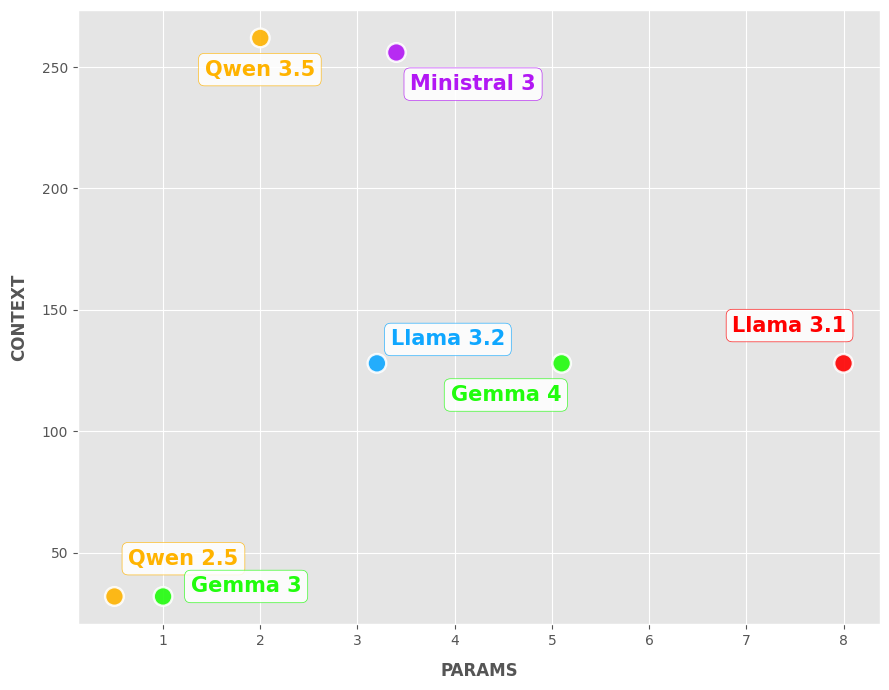

In [31]:
data = [
    {"model": "Llama 3.1", "params": 8.0, "context": 128, "color": "#FF0000", "xytext": (-80, 20)},
    {"model": "Llama 3.2", "params": 3.2, "context": 128, "color": "#0FA7FF", "xytext": (10, 10)},
    {"model": "Qwen 2.5", "params": 0.5, "context": 32, "color": "#FFB300", "xytext": (10, 20)},
    {"model": "Qwen 3.5", "params": 2.0, "context": 262, "color": "#FFB300", "xytext": (-40, -30)},
    {"model": "Ministral 3", "params": 3.4, "context": 256, "color": "#B217F4", "xytext": (10, -30)},
    {"model": "Gemma 3", "params": 1.0, "context": 32, "color": "#21FD0D", "xytext": (20, 0)},
    {"model": "Gemma 4", "params": 5.1, "context": 128, "color": "#21FD0D", "xytext": (-80, -30)}
]
data = update_score(data)

drawing(data, x_col="params", y_col="context", label="model")

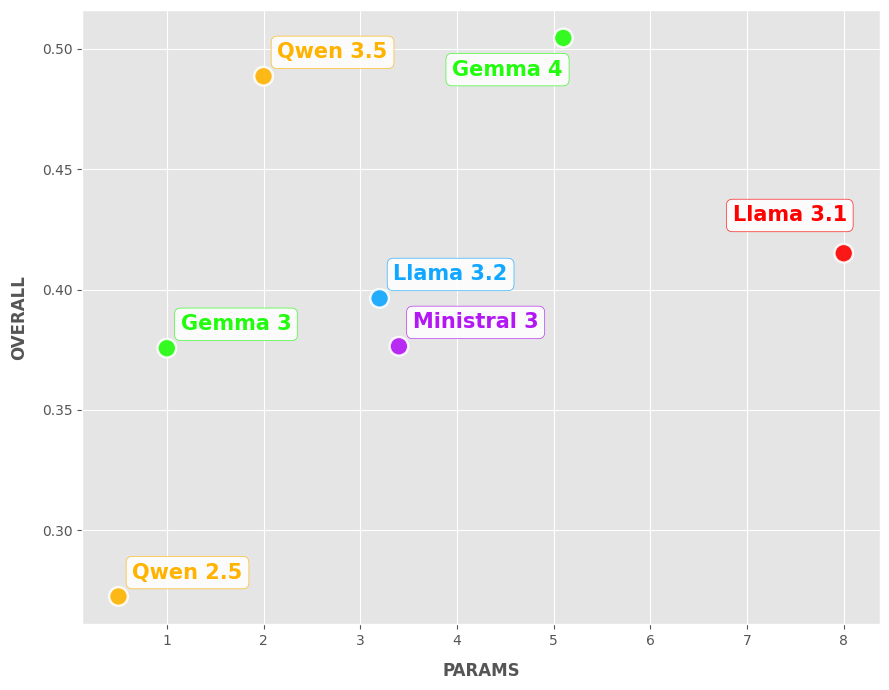

In [32]:
data = [
    {"model": "Llama 3.1", "params": 8.0, "context": 128, "color": "#FF0000", "xytext": (-80, 20)},
    {"model": "Llama 3.2", "params": 3.2, "context": 128, "color": "#0FA7FF", "xytext": (10, 10)},
    {"model": "Qwen 2.5", "params": 0.5, "context": 32, "color": "#FFB300", "xytext": (10, 10)},
    {"model": "Qwen 3.5", "params": 2.0, "context": 262, "color": "#FFB300", "xytext": (10, 10)},
    {"model": "Ministral 3", "params": 3.4, "context": 256, "color": "#B217F4", "xytext": (10, 10)},
    {"model": "Gemma 3", "params": 1.0, "context": 32, "color": "#21FD0D", "xytext": (10, 10)},
    {"model": "Gemma 4", "params": 5.1, "context": 128, "color": "#21FD0D", "xytext": (-80, -30)}
]
data = update_score(data)

drawing(data, x_col="params", y_col="overall", label="model")

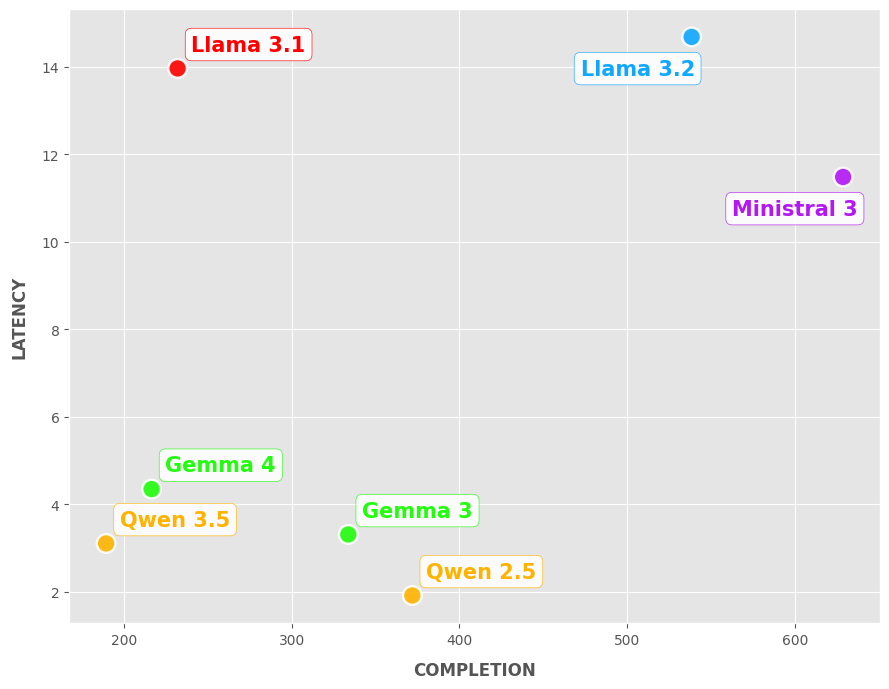

In [33]:
data = [
    {"model": "Llama 3.1", "params": 8.0, "context": 128, "color": "#FF0000", "xytext": (10, 10)},
    {"model": "Llama 3.2", "params": 3.2, "context": 128, "color": "#0FA7FF", "xytext": (-80, -30)},
    {"model": "Qwen 2.5", "params": 0.5, "context": 32, "color": "#FFB300", "xytext": (10, 10)},
    {"model": "Qwen 3.5", "params": 2.0, "context": 262, "color": "#FFB300", "xytext": (10, 10)},
    {"model": "Ministral 3", "params": 3.4, "context": 256, "color": "#B217F4", "xytext": (-80, -30)},
    {"model": "Gemma 3", "params": 1.0, "context": 32, "color": "#21FD0D", "xytext": (10, 10)},
    {"model": "Gemma 4", "params": 5.1, "context": 128, "color": "#21FD0D", "xytext": (10, 10)}
]
data = update_score(data)

drawing(data, x_col="completion", y_col="latency", label="model")

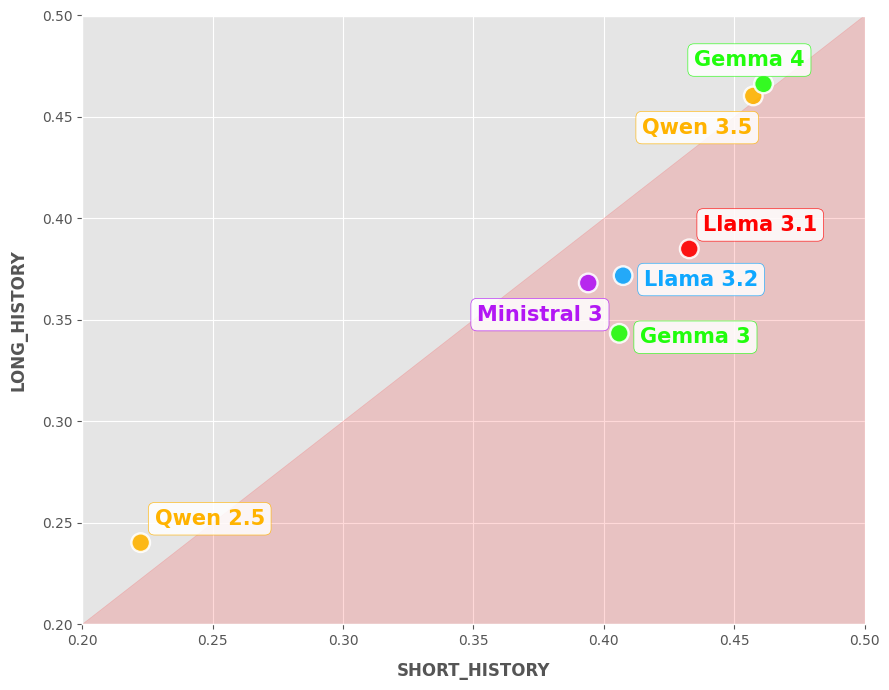

In [34]:
data = [
    {"model": "Llama 3.1", "params": 8.0, "context": 128, "color": "#FF0000", "xytext": (10, 10)},
    {"model": "Llama 3.2", "params": 3.2, "context": 128, "color": "#0FA7FF", "xytext": (15, -10)},
    {"model": "Qwen 2.5", "params": 0.5, "context": 32, "color": "#FFB300", "xytext": (10, 10)},
    {"model": "Qwen 3.5", "params": 2.0, "context": 262, "color": "#FFB300", "xytext": (-80, -30)},
    {"model": "Ministral 3", "params": 3.4, "context": 256, "color": "#B217F4", "xytext": (-80, -30)},
    {"model": "Gemma 3", "params": 1.0, "context": 32, "color": "#21FD0D", "xytext": (15, -10)},
    {"model": "Gemma 4", "params": 5.1, "context": 128, "color": "#21FD0D", "xytext": (-50, 10)}
]
data = update_score(data)

drawing(data, x_col="short_history", y_col="long_history", label="model", add_triangle=True, xlim=(0.2, 0.5), ylim=(0.2, 0.5))

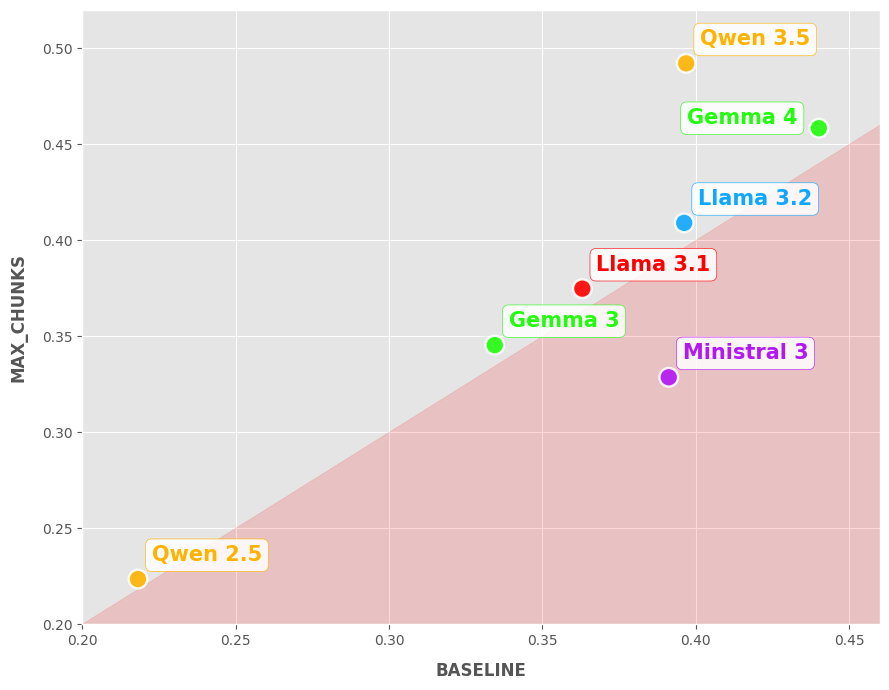

In [35]:
data = [
    {"model": "Llama 3.1", "params": 8.0, "context": 128, "color": "#FF0000", "xytext": (10, 10)},
    {"model": "Llama 3.2", "params": 3.2, "context": 128, "color": "#0FA7FF", "xytext": (10, 10)},
    {"model": "Qwen 2.5", "params": 0.5, "context": 32, "color": "#FFB300", "xytext": (10, 10)},
    {"model": "Qwen 3.5", "params": 2.0, "context": 262, "color": "#FFB300", "xytext": (10, 10)},
    {"model": "Ministral 3", "params": 3.4, "context": 256, "color": "#B217F4", "xytext": (10, 10)},
    {"model": "Gemma 3", "params": 1.0, "context": 32, "color": "#21FD0D", "xytext": (10, 10)},
    {"model": "Gemma 4", "params": 5.1, "context": 128, "color": "#21FD0D", "xytext": (-95, 0)}
]
data = update_score(data)

drawing(data, x_col="baseline", y_col="max_chunks", label="model", add_triangle=True, xlim=(0.2, 0.46), ylim=(0.2, 0.52))

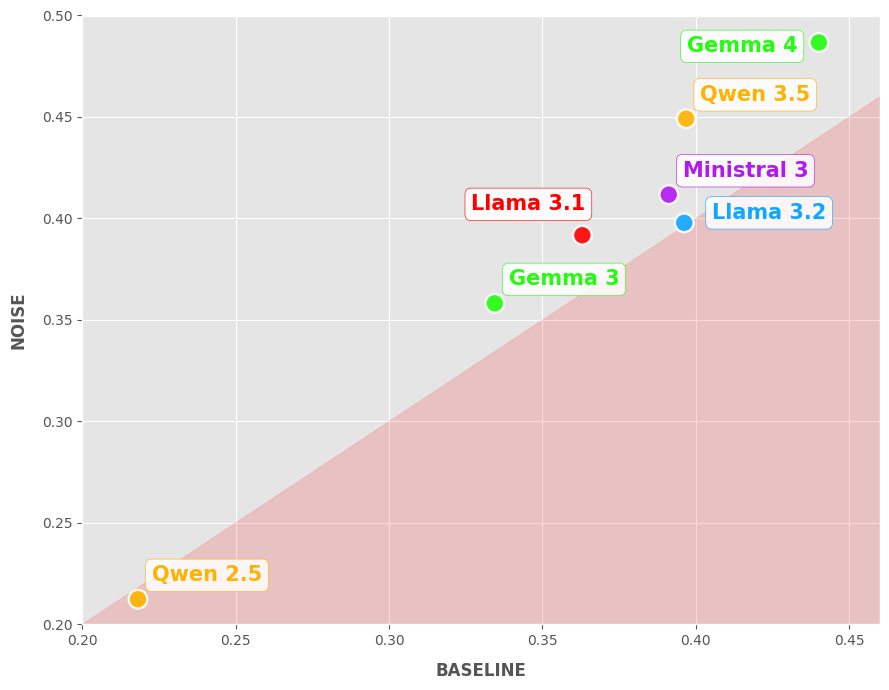

In [43]:
data = [
    {"model": "Llama 3.1", "params": 8.0, "context": 128, "color": "#FF0000", "xytext": (-80, 15)},
    {"model": "Llama 3.2", "params": 3.2, "context": 128, "color": "#0FA7FF", "xytext": (20, 0)},
    {"model": "Qwen 2.5", "params": 0.5, "context": 32, "color": "#FFB300", "xytext": (10, 10)},
    {"model": "Qwen 3.5", "params": 2.0, "context": 262, "color": "#FFB300", "xytext": (10, 10)},
    {"model": "Ministral 3", "params": 3.4, "context": 256, "color": "#B217F4", "xytext": (10, 10)},
    {"model": "Gemma 3", "params": 1.0, "context": 32, "color": "#21FD0D", "xytext": (10, 10)},
    {"model": "Gemma 4", "params": 5.1, "context": 128, "color": "#21FD0D", "xytext": (-95, -10)}
]
data = update_score(data)

drawing(data, x_col="baseline", y_col="noise", label="model", add_triangle=True, xlim=(0.2, 0.46), ylim=(0.2, 0.5))

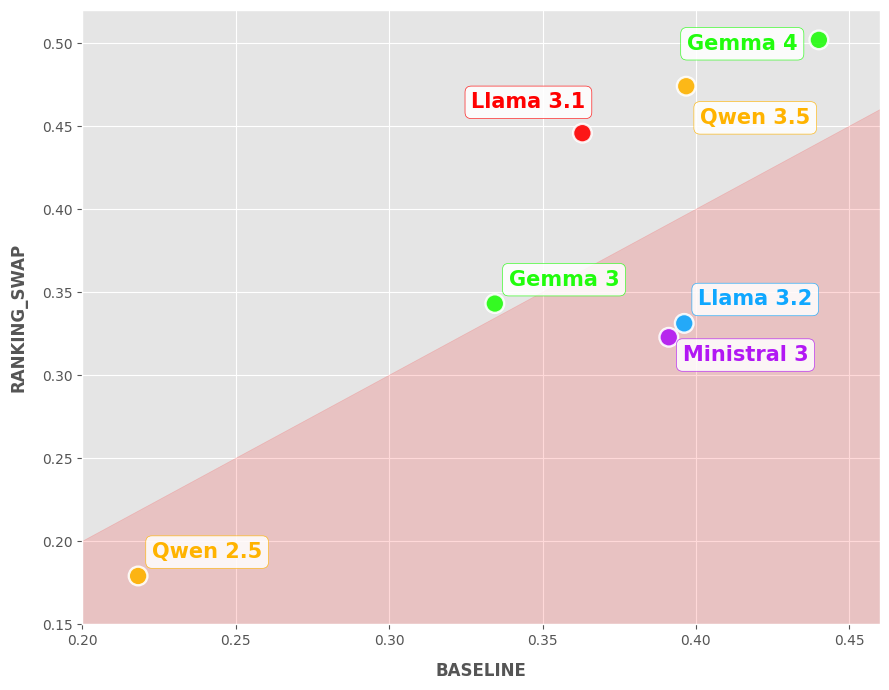

In [37]:
data = [
    {"model": "Llama 3.1", "params": 8.0, "context": 128, "color": "#FF0000", "xytext": (-80, 15)},
    {"model": "Llama 3.2", "params": 3.2, "context": 128, "color": "#0FA7FF", "xytext": (10, 10)},
    {"model": "Qwen 2.5", "params": 0.5, "context": 32, "color": "#FFB300", "xytext": (10, 10)},
    {"model": "Qwen 3.5", "params": 2.0, "context": 262, "color": "#FFB300", "xytext": (10, -30)},
    {"model": "Ministral 3", "params": 3.4, "context": 256, "color": "#B217F4", "xytext": (10, -20)},
    {"model": "Gemma 3", "params": 1.0, "context": 32, "color": "#21FD0D", "xytext": (10, 10)},
    {"model": "Gemma 4", "params": 5.1, "context": 128, "color": "#21FD0D", "xytext": (-95, -10)}
]
data = update_score(data)

drawing(data, x_col="baseline", y_col="ranking_swap", label="model", add_triangle=True, xlim=(0.2, 0.46), ylim=(0.15, 0.52))

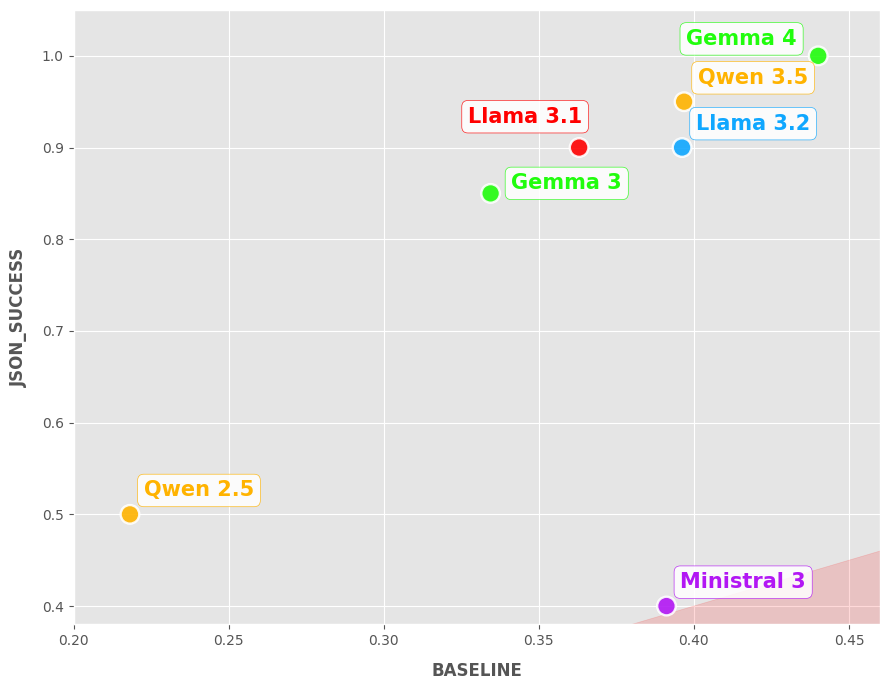

In [38]:
data = [
    {"model": "Llama 3.1", "params": 8.0, "context": 128, "color": "#FF0000", "xytext": (-80, 15)},
    {"model": "Llama 3.2", "params": 3.2, "context": 128, "color": "#0FA7FF", "xytext": (10, 10)},
    {"model": "Qwen 2.5", "params": 0.5, "context": 32, "color": "#FFB300", "xytext": (10, 10)},
    {"model": "Qwen 3.5", "params": 2.0, "context": 262, "color": "#FFB300", "xytext": (10, 10)},
    {"model": "Ministral 3", "params": 3.4, "context": 256, "color": "#B217F4", "xytext": (10, 10)},
    {"model": "Gemma 3", "params": 1.0, "context": 32, "color": "#21FD0D", "xytext": (15, 0)},
    {"model": "Gemma 4", "params": 5.1, "context": 128, "color": "#21FD0D", "xytext": (-95, 5)}
]
data = update_score(data)

drawing(data, x_col="baseline", y_col="json_success", label="model", add_triangle=True, xlim=(0.2, 0.46), ylim=(0.38, 1.05))

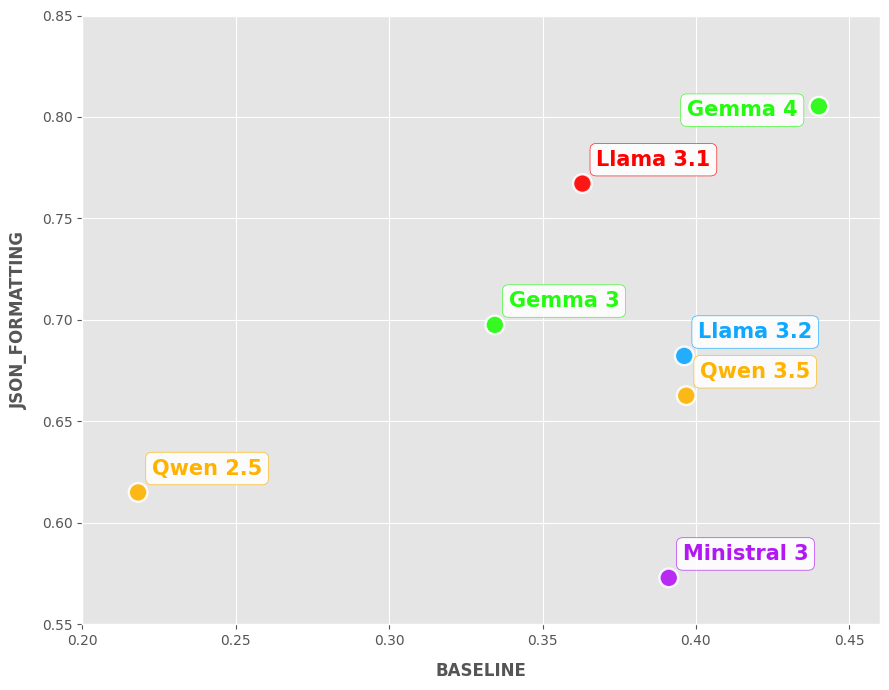

In [39]:
data = [
    {"model": "Llama 3.1", "params": 8.0, "context": 128, "color": "#FF0000", "xytext": (10, 10)},
    {"model": "Llama 3.2", "params": 3.2, "context": 128, "color": "#0FA7FF", "xytext": (10, 10)},
    {"model": "Qwen 2.5", "params": 0.5, "context": 32, "color": "#FFB300", "xytext": (10, 10)},
    {"model": "Qwen 3.5", "params": 2.0, "context": 262, "color": "#FFB300", "xytext": (10, 10)},
    {"model": "Ministral 3", "params": 3.4, "context": 256, "color": "#B217F4", "xytext": (10, 10)},
    {"model": "Gemma 3", "params": 1.0, "context": 32, "color": "#21FD0D", "xytext": (10, 10)},
    {"model": "Gemma 4", "params": 5.1, "context": 128, "color": "#21FD0D", "xytext": (-95, -10)}
]
data = update_score(data)

drawing(data, x_col="baseline", y_col="json_formatting", label="model", add_triangle=True, xlim=(0.2, 0.46), ylim=(0.55, 0.85))

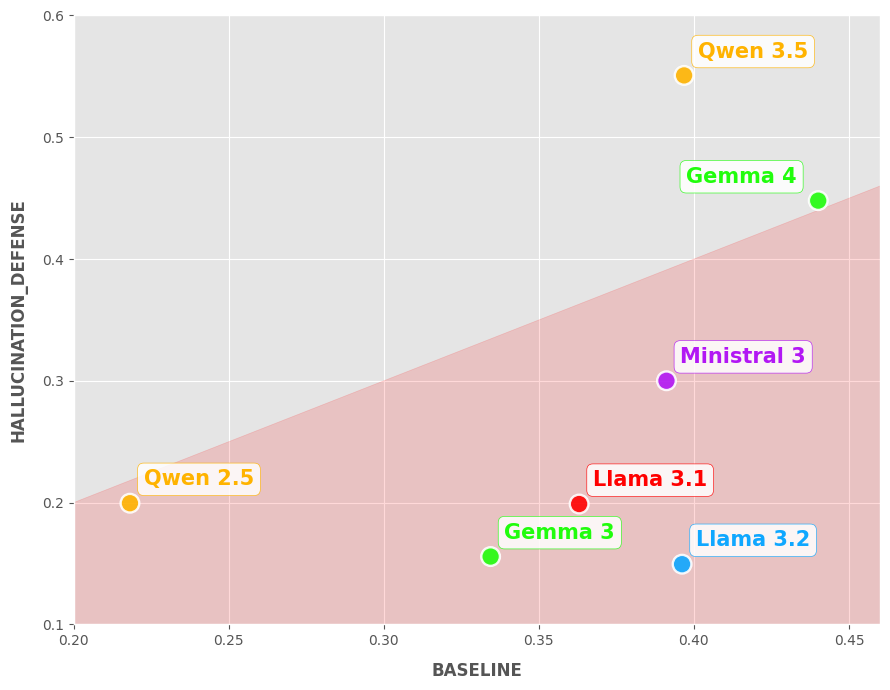

In [40]:
data = [
    {"model": "Llama 3.1", "params": 8.0, "context": 128, "color": "#FF0000", "xytext": (10, 10)},
    {"model": "Llama 3.2", "params": 3.2, "context": 128, "color": "#0FA7FF", "xytext": (10, 10)},
    {"model": "Qwen 2.5", "params": 0.5, "context": 32, "color": "#FFB300", "xytext": (10, 10)},
    {"model": "Qwen 3.5", "params": 2.0, "context": 262, "color": "#FFB300", "xytext": (10, 10)},
    {"model": "Ministral 3", "params": 3.4, "context": 256, "color": "#B217F4", "xytext": (10, 10)},
    {"model": "Gemma 3", "params": 1.0, "context": 32, "color": "#21FD0D", "xytext": (10, 10)},
    {"model": "Gemma 4", "params": 5.1, "context": 128, "color": "#21FD0D", "xytext": (-95, 10)}
]
data = update_score(data)

drawing(data, x_col="baseline", y_col="hallucination_defense", label="model", add_triangle=True, xlim=(0.2, 0.46), ylim=(0.1, 0.6))